# 🏡 Airbnb Listings — Deep Dive Analysis

**Dataset:** 953 Airbnb listings scraped from the platform  
**Goal:** Explore pricing, amenities, location patterns, and listing themes through structured feature extraction and statistical analysis.

---

## 📋 Notebook Structure

| Section | What Happens |
|---|---|
| **1 · Setup** | Imports and module loading |
| **2 · Raw Data Load** | Read CSV, inspect shape and column types |
| **3 · Initial Exploration** | Missing values, duplicates, unique counts |
| **4 · Sample Rows** | Visual sanity-check of raw data |
| **5 · Feature Extraction** | Parse `Title` and `Detail` → 22 new structured columns (7 → 29) |
| **6 · Data Cleaning** | Parse prices, ratings, bed info, dates → 13 more columns (29 → 42) |
| **7 · Column Audit** | Full list of all 42 columns with dtypes |
| **8 · Spot Check** | Explore a specific column in depth |
| **9 · Prepare for Analysis** | Drop redundant columns, reorder → clean 32-column DataFrame |
| **10 · Save to Parquet** | Persist the cleaned DataFrame to disk for future use |
| **11 · Reload from Parquet** | Fast entry point — skip the pipeline on subsequent runs |

> **⚡ Quick Start:** If `cleaned_and_processed_data.parquet` already exists, jump directly to **Section 11** and skip Sections 2–10.


## 1 · Setup

Import the standard libraries and all custom modules.  
Each module is responsible for a distinct stage of the pipeline:

- `data_loader.py` — CSV loading and initial exploration helpers  
- `feature_extraction.py` — Regex/keyword-based column creation from `Title` and `Detail`  
- `data_cleaning.py` — Type conversion and parsing for prices, ratings, beds, and dates  
- `analysis.py` — Final column selection, parquet persistence, and (future) visualizations


## 2 · Raw Data Load

Load the raw CSV file. The dataset starts with **7 columns**, all stored as plain strings — no numeric types yet.


In [ ]:
import pandas as pd
from data_loader import load_data, explore_data, show_sample, show_column_summary
from feature_extraction import extract_all_features
from data_cleaning import clean_all_columns
from analysis import prepare_analysis_df, save_analysis_df, load_analysis_df, parquet_exists


In [ ]:
df = load_data()

## 3 · Initial Data Exploration

Get a structural overview of the raw DataFrame:
- **Shape** — 953 rows × 7 columns
- **Dtypes & null counts** — everything is `str`; `Offer price` is 82.6% missing
- **Duplicates** — 34 duplicate rows (3.57%)
- **Unique values** — high cardinality in `Title`, `Detail`, and `Review and rating`


In [ ]:
explore_data(df)


## 4 · Sample Rows

A quick visual look at the first 5 rows to understand the raw string formats.

Key observations:
- `Title` encodes **property type + full location** in one string (e.g., *"Cabin in Hancock, New York, US"*)
- `Detail` is a short marketing tagline, not a full description
- `Date` is a range string (e.g., *"Jun 11 - 16"*)
- `Price(in dollar)` and `Offer price(in dollar)` are decimal strings, not floats
- `Review and rating` combines rating score and review count (e.g., *"4.85 (531)"*)


In [ ]:
show_sample(df)


## 5 · Feature Extraction  `(7 → 29 columns)`

Apply `extract_all_features()` from `feature_extraction.py`.  
This parses the unstructured `Title` and `Detail` columns using **regex patterns and keyword scoring** to produce 22 new analysis-ready columns:

| Group | New Columns |
|---|---|
| **From Title** | `Property_Type`, `City`, `State`, `Country` |
| **Amenity flags** | `Has_Hot_Tub`, `Has_Sauna`, `Has_Pool`, `Has_BBQ`, `Has_Fireplace`, `Has_Parking`, `Has_Spa` |
| **Location flags** | `Has_Waterfront`, `Is_Near_Beach`, `Is_Mountain`, `Is_Rural`, `Is_Urban` |
| **Classification** | `Property_Subtype`, `Theme` |
| **Text metrics** | `Detail_Word_Count`, `Detail_Char_Count`, `Has_Promo`, `Bedroom_Count` |


In [ ]:
df = extract_all_features(df)
print("Shape after feature extraction:", df.shape)
df.head()


## 6 · Data Cleaning  `(29 → 42 columns)`

Apply `clean_all_columns()` from `data_cleaning.py`.  
This converts the raw string columns into properly-typed numeric and categorical columns, adding 13 more:

| Source Column | New Columns Derived |
|---|---|
| `Price(in dollar)` | `Price` (float) |
| `Offer price(in dollar)` | `Offer_Price` (float), `Discount_Pct` (%) |
| `Review and rating` | `Rating` (float), `Review_Count` (int), `Is_New_Listing` (bool) |
| `Number of bed` | `Bed_Count` (int), `Bed_Type` (str) |
| `Date` | `Month`, `Start_Day`, `End_Day`, `Duration_Nights`, `Price_Per_Night` |


In [ ]:
df = clean_all_columns(df)
print("Shape after cleaning:", df.shape)
df.head()


## 7 · Full Column Audit

Print all 42 columns with their datatypes and non-null counts to confirm the pipeline ran correctly.


In [ ]:
print(f"Total columns: {df.shape[1]}\n")
for i, col in enumerate(df.columns, 1):
    dtype = df[col].dtype
    non_null = df[col].notna().sum()
    print(f"  {i:2d}. {col:<25s} {str(dtype):<10s} ({non_null} non-null)")


## 8 · Spot Check — Column Deep Dive

Use `show_column_summary()` to inspect any individual column.  
Currently profiling `Country` — **251 listings return "Unknown"** because many international listing titles don't follow the standard `"Type in City, State, Country"` format.

> Uncomment other columns below to inspect `Theme`, `Price`, or `Rating`.


In [ ]:
show_column_summary(df, "Country")
# show_column_summary(df, "Theme")
# show_column_summary(df, "Price")
# show_column_summary(df, "Rating")


## 9 · Prepare Analysis DataFrame & Save to Parquet

`prepare_analysis_df()` drops the 10 redundant/low-value columns (the original 7 raw strings + `Bedroom_Count`, `Start_Day`, `End_Day`) and reorders the remaining **32 columns** into logical groups:

`Location → Pricing → Reviews → Beds → Dates → Amenities → Location Flags → Classification → Text Metrics`

The cleaned DataFrame is then saved to disk as a **Parquet file** using `fastparquet`, so this expensive pipeline doesn't need to run again.

> 📁 Output: `../data/cleaned_and_processed_data.parquet`


In [ ]:
# First time — run full pipeline and save:
df = prepare_analysis_df(df)
save_analysis_df(df)


## 10 · Reload from Parquet  *(Subsequent-Run Entry Point)*

---

> ### ⚡ Start here on all future runs
> 
> If `cleaned_and_processed_data.parquet` already exists, **run only this cell** instead of re-executing the full pipeline above.  
> It loads the clean, 32-column analysis-ready DataFrame directly from disk in milliseconds.

---


In [13]:
import pandas as pd
from data_loader import load_data, explore_data, show_sample, show_column_summary
from feature_extraction import extract_all_features
from data_cleaning import clean_all_columns
from analysis import prepare_analysis_df, save_analysis_df, load_analysis_df, parquet_exists, univariate_bar_plot, univariate_pie_plot, univariate_violin_plot


In [14]:
# Subsequent times — skip the pipeline, just load:
if parquet_exists():
    df = load_analysis_df()


[OK] Loaded analysis DataFrame ← c:\Users\lenov\OneDrive\Desktop\ai-project-collection\Airbnb-Listings-Deep-Dive\data\cleaned_and_processed_data.parquet  (953 rows × 32 cols)


## 11 · Verify the Loaded DataFrame

Confirm the final analysis DataFrame looks correct — 953 rows, 32 clean columns, all properly typed.

In [15]:
df.head()

,Property_Type,Property_Subtype,City,State,Country,Price,Offer_Price,Discount_Pct,Price_Per_Night,Rating,...,Has_Spa,Has_Waterfront,Is_Near_Beach,Is_Mountain,Is_Rural,Is_Urban,Theme,Detail_Word_Count,Detail_Char_Count,Has_Promo
0,Chalet,A-Frame,Skykomish,Washington,US,306.0,229.0,25.16,61.2,4.85,...,False,False,False,False,False,False,Nature,5,24,False
1,Cabin,A-Frame,Hancock,New York,US,485.0,170.0,64.95,97.0,4.77,...,False,False,False,False,False,False,Nature,7,47,False
2,Cabin,A-Frame,West Farmington,Ohio,US,119.0,522.0,-338.66,23.8,4.91,...,False,False,False,False,True,False,Nature,8,49,False
3,Home,Other,Blue Ridge,Georgia,US,192.0,348.0,-81.25,38.4,4.94,...,False,False,False,True,False,False,General,10,50,False
4,Treehouse,Treehouse,Grandview,Texas,US,232.0,196.0,15.52,46.4,4.99,...,False,False,False,False,False,False,Luxury,7,50,False


In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 953 entries, 0 to 952
Data columns (total 32 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Property_Type      953 non-null    string 
 1   Property_Subtype   953 non-null    string 
 2   City               953 non-null    string 
 3   State              953 non-null    string 
 4   Country            953 non-null    string 
 5   Price              953 non-null    float64
 6   Offer_Price        166 non-null    float64
 7   Discount_Pct       166 non-null    float64
 8   Price_Per_Night    888 non-null    float64
 9   Rating             931 non-null    float64
 10  Review_Count       947 non-null    float64
 11  Is_New_Listing     953 non-null    bool   
 12  Bed_Count          953 non-null    int64  
 13  Bed_Type           953 non-null    string 
 14  Month              953 non-null    string 
 15  Duration_Nights    888 non-null    float64
 16  Has_Hot_Tub        953 non-null    bo

In [17]:
# from data_loader import show_column_summary
# show_column_summary(df,"Property_Type")

## 12. Univariate Analysis

String Columns

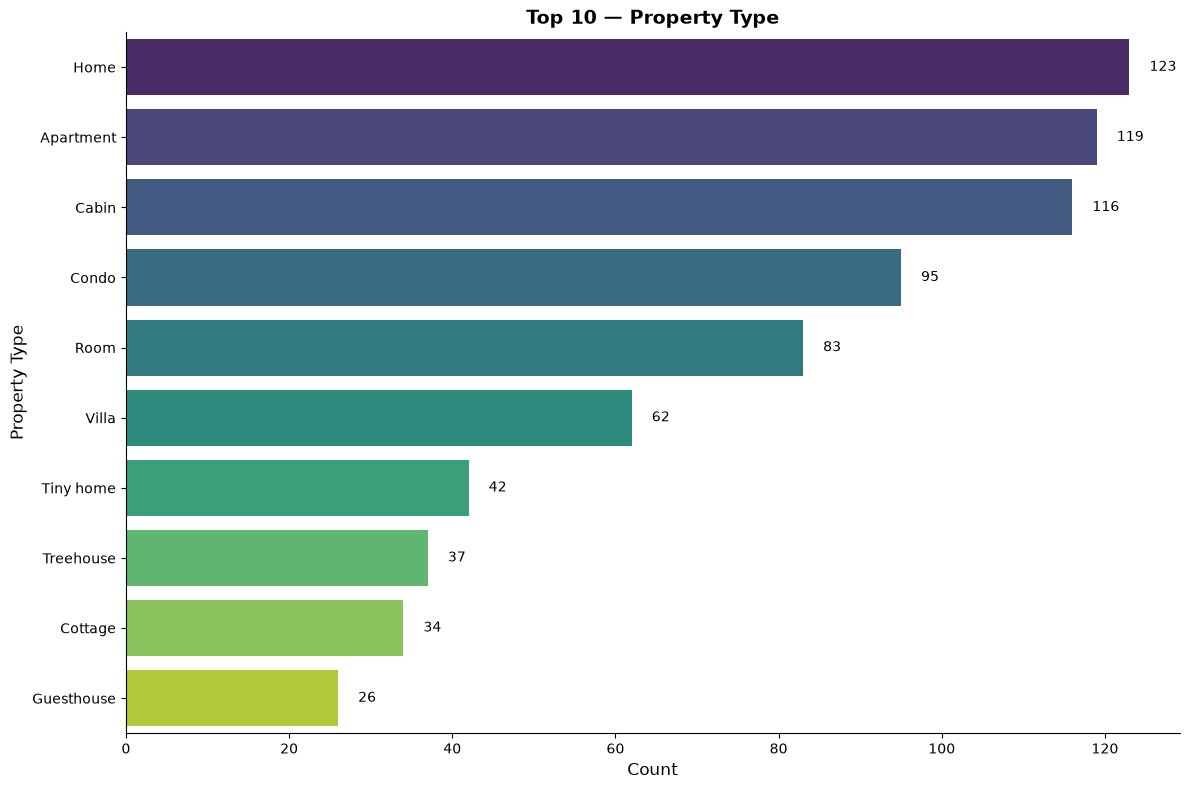

In [18]:
univariate_bar_plot(df, "Property_Type")


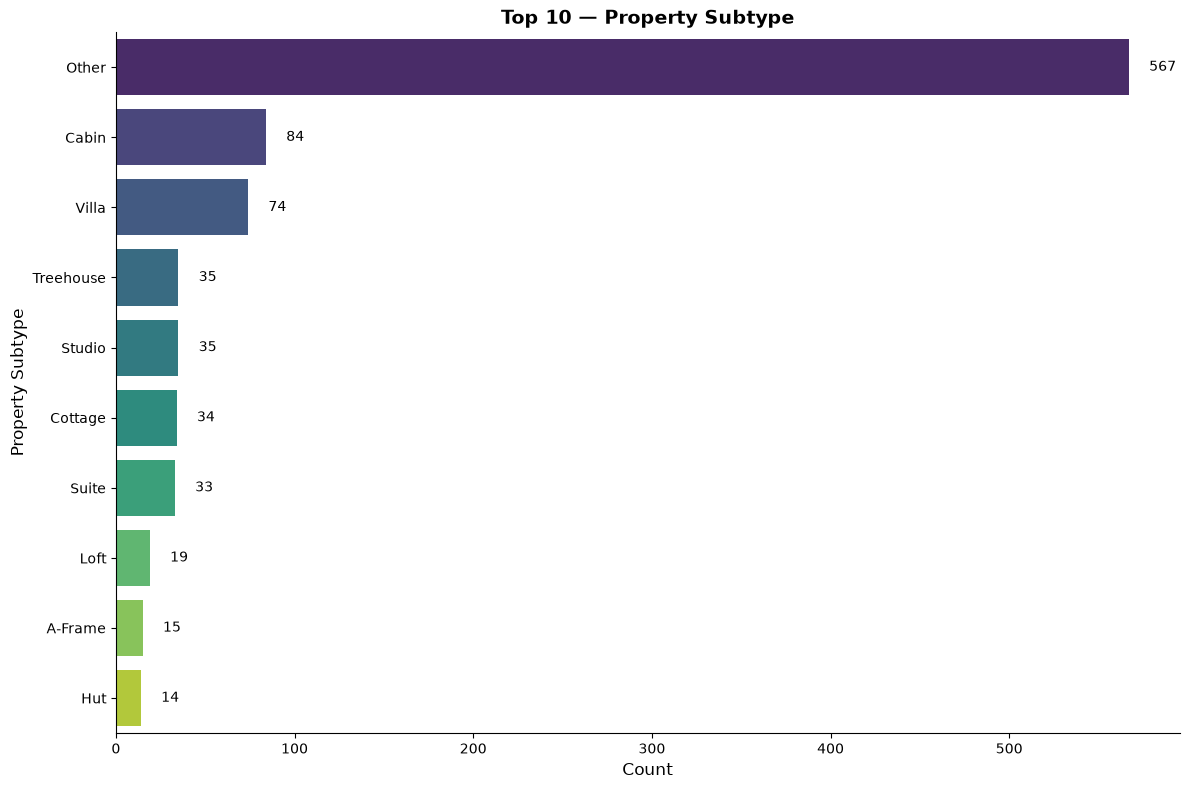

In [19]:
univariate_bar_plot(df, "Property_Subtype")


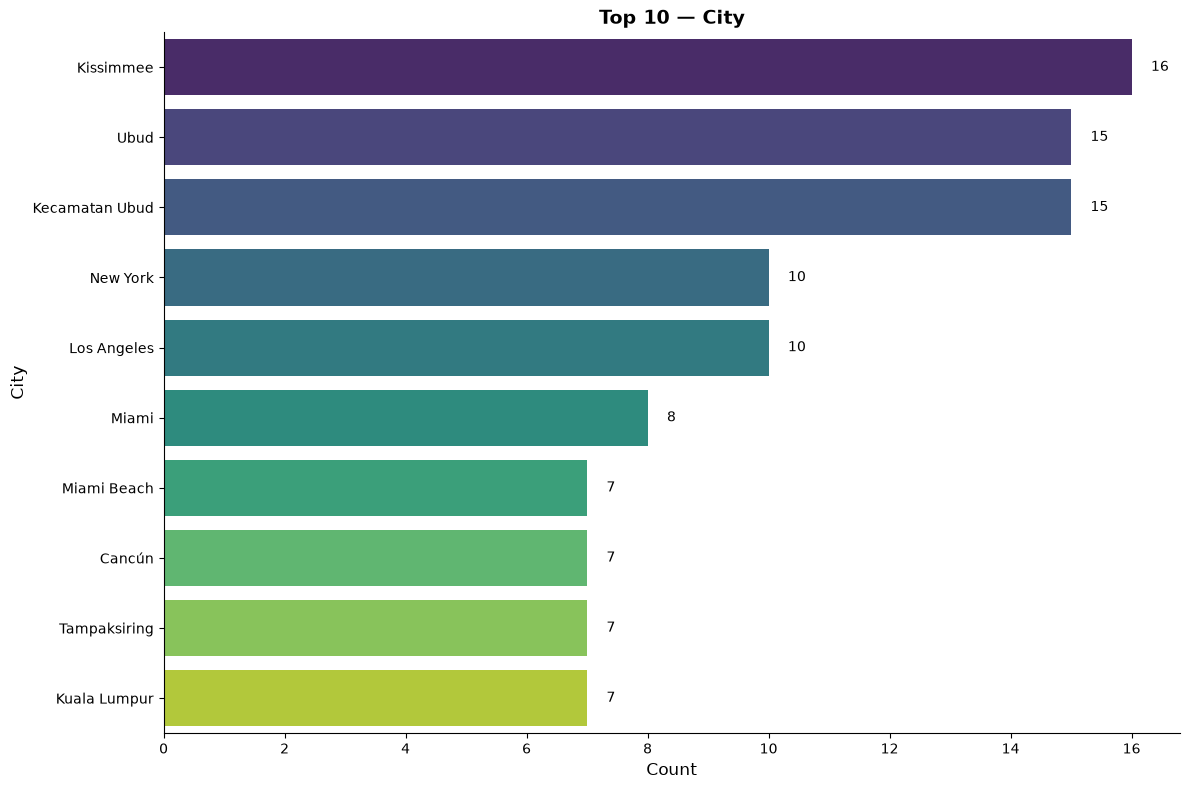

In [20]:
univariate_bar_plot(df, "City")


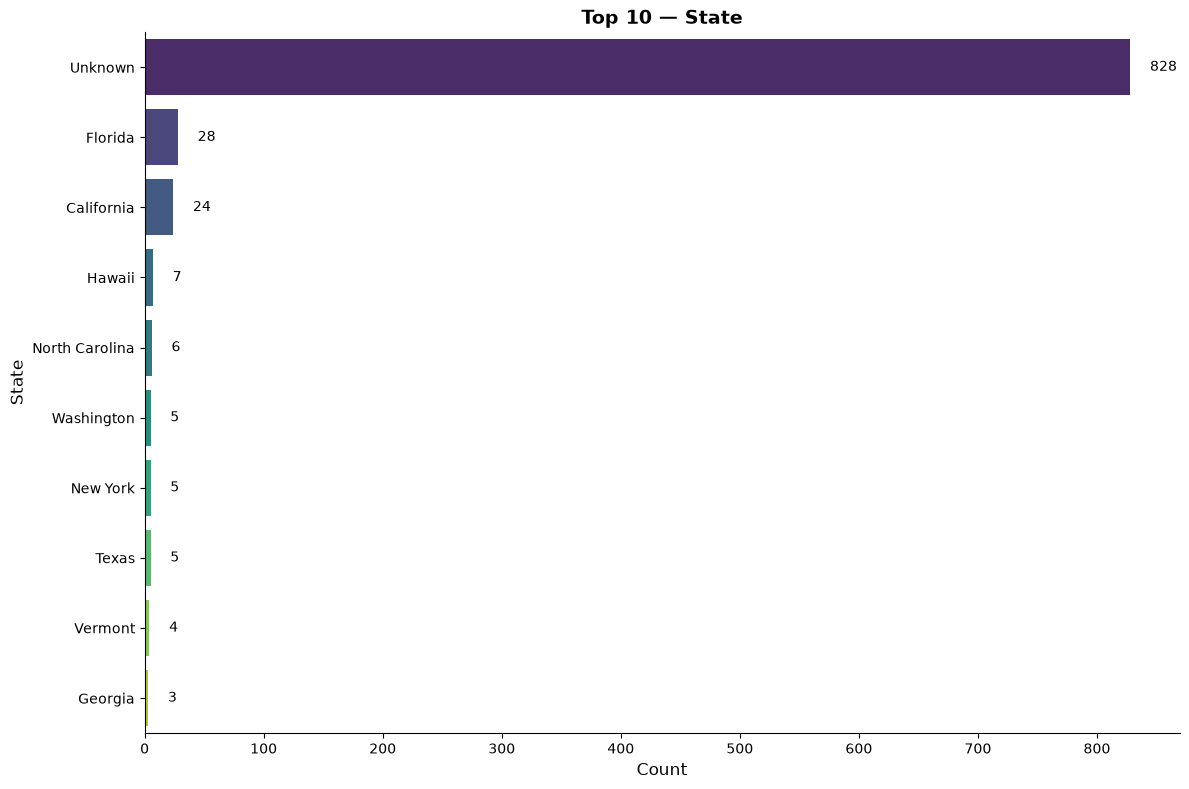

In [21]:
univariate_bar_plot(df, "State")


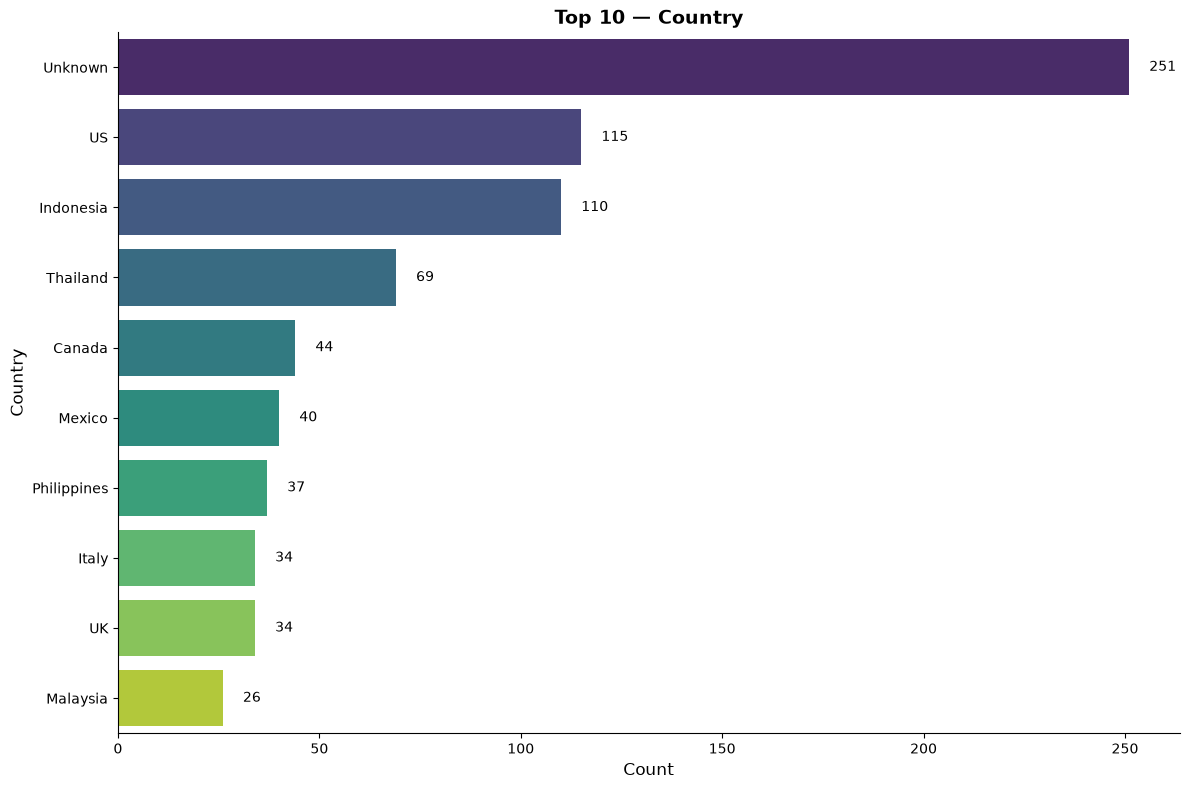

In [22]:
univariate_bar_plot(df, "Country")


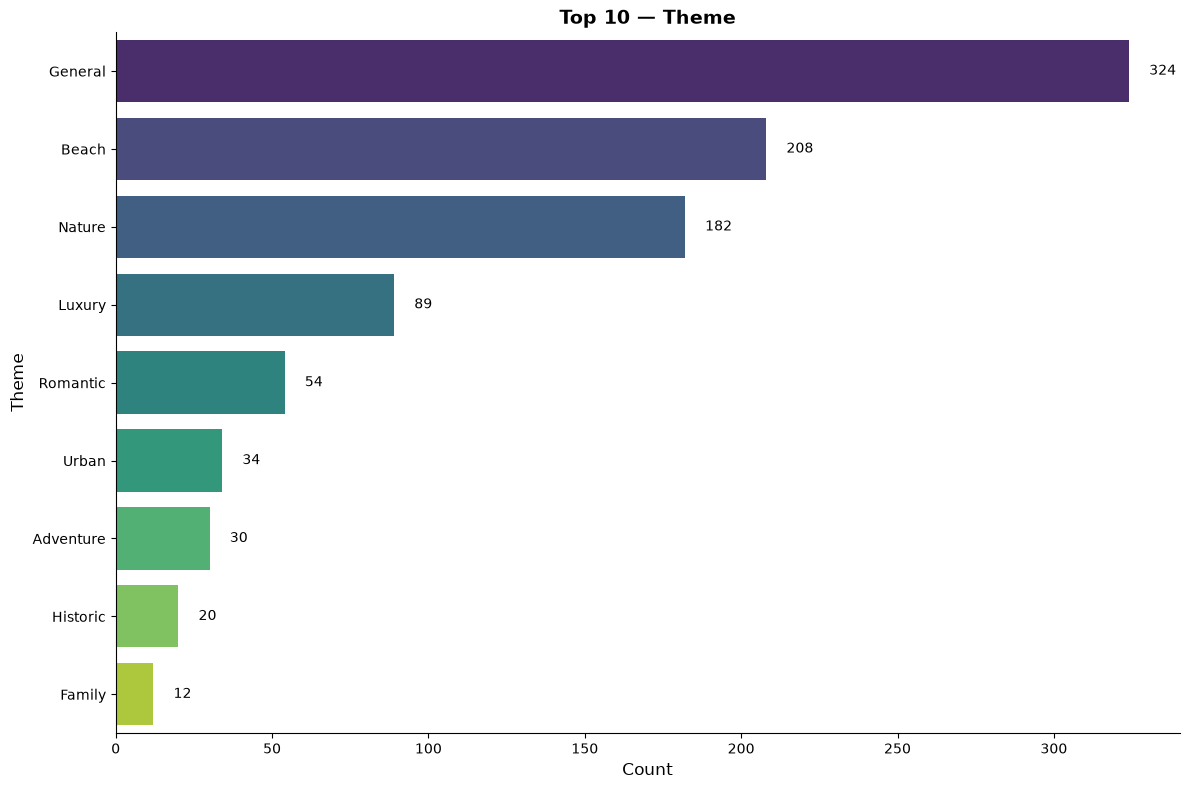

In [23]:
univariate_bar_plot(df, "Theme")


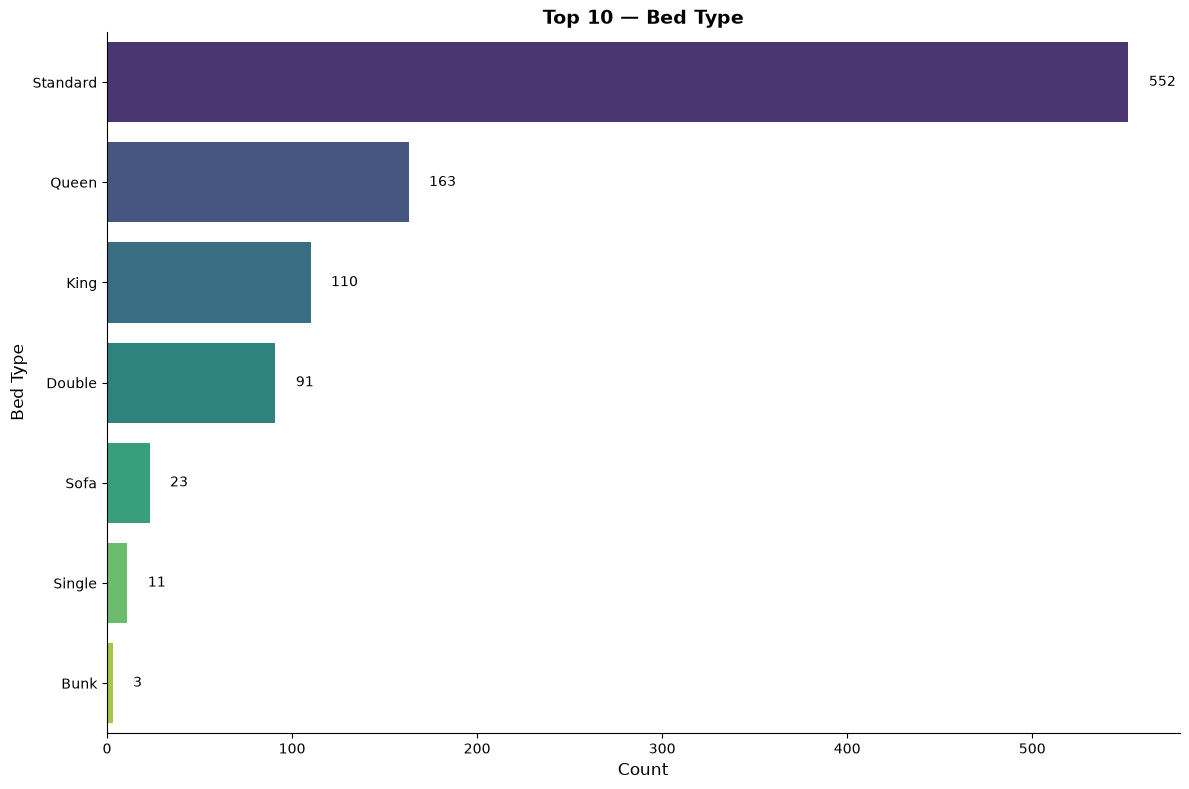

In [24]:
univariate_bar_plot(df, "Bed_Type")


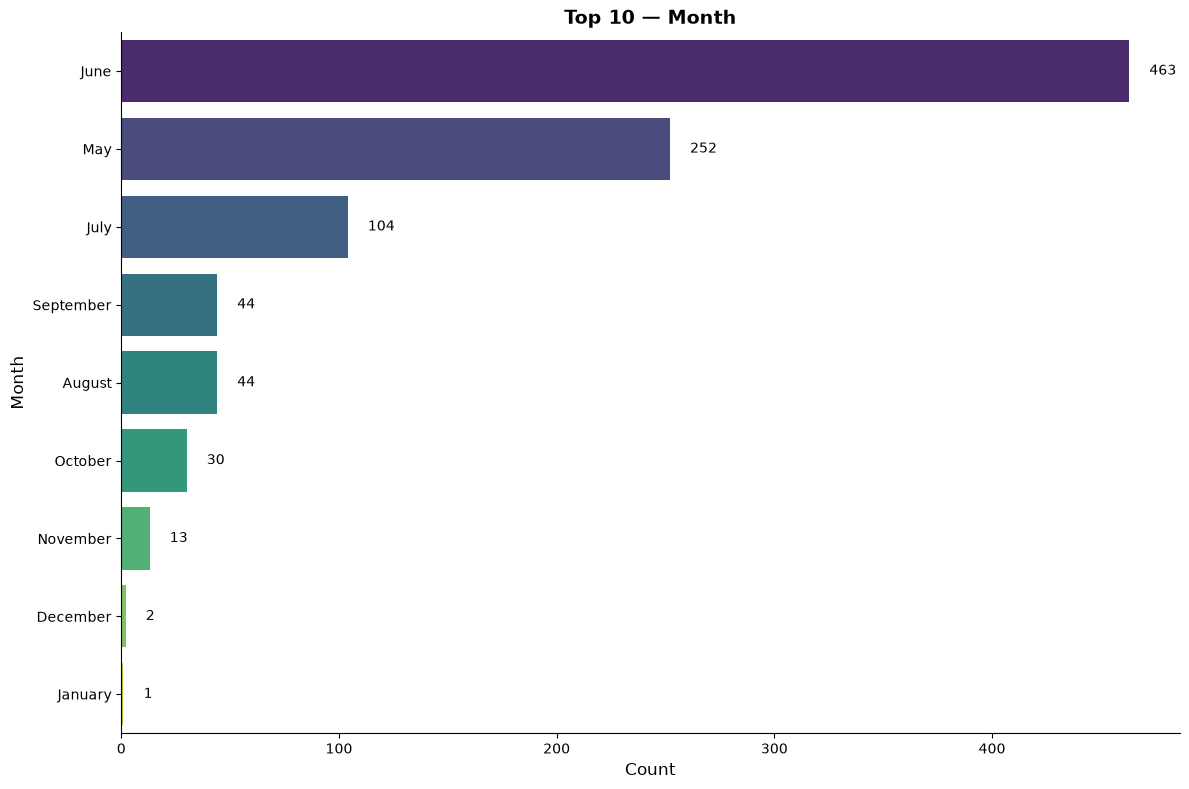

In [25]:
univariate_bar_plot(df, "Month")


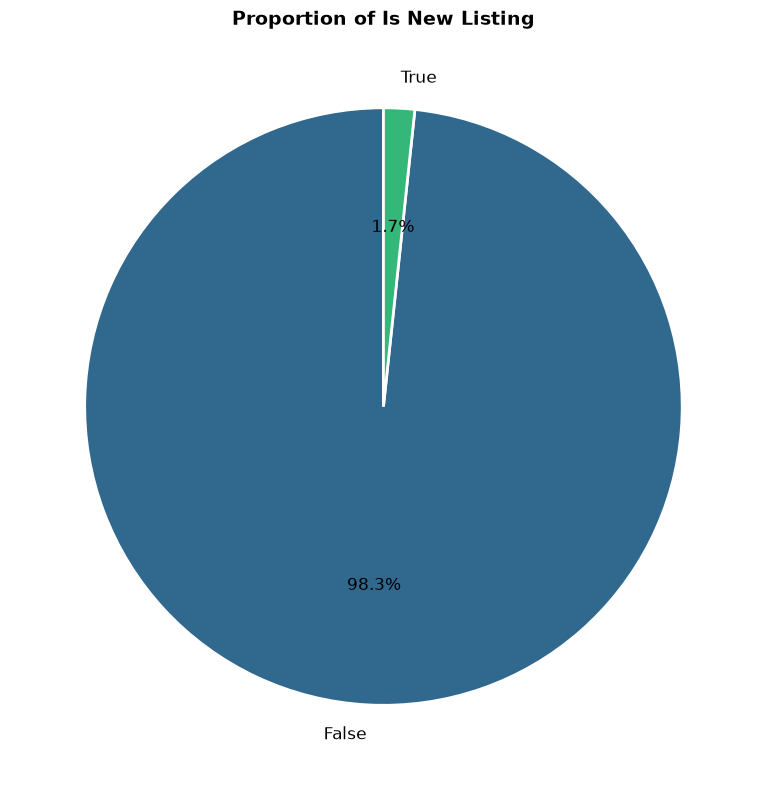

In [26]:
univariate_pie_plot(df,"Is_New_Listing")


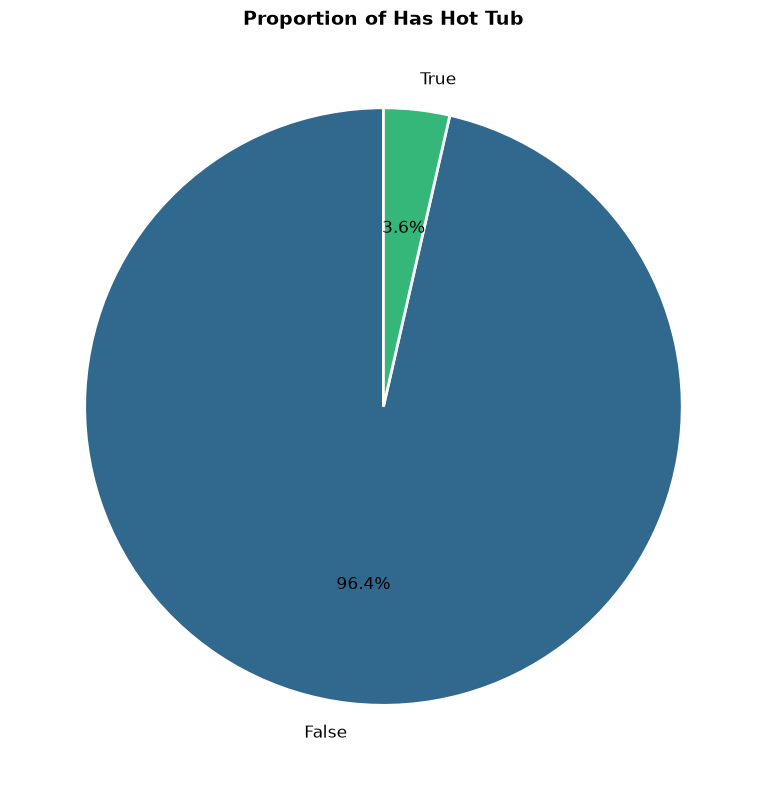

In [27]:
univariate_pie_plot(df,"Has_Hot_Tub")


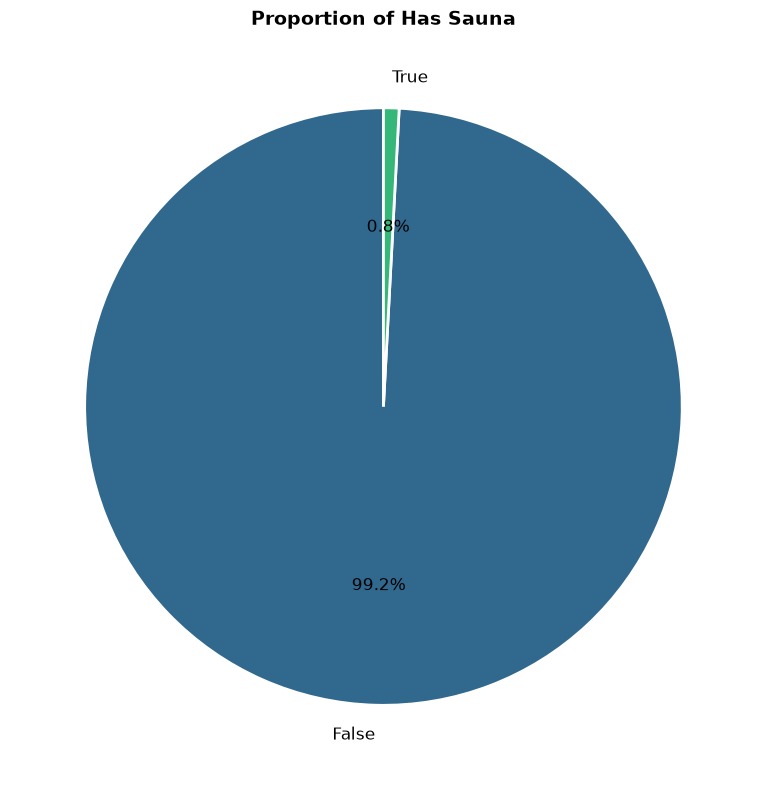

In [28]:
univariate_pie_plot(df,"Has_Sauna")


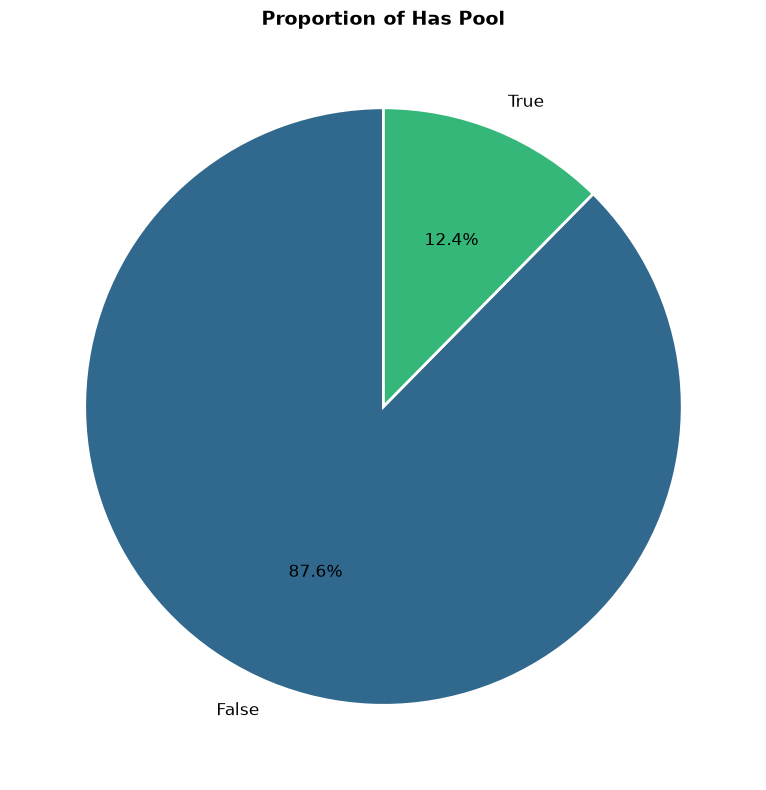

In [29]:
univariate_pie_plot(df,"Has_Pool")


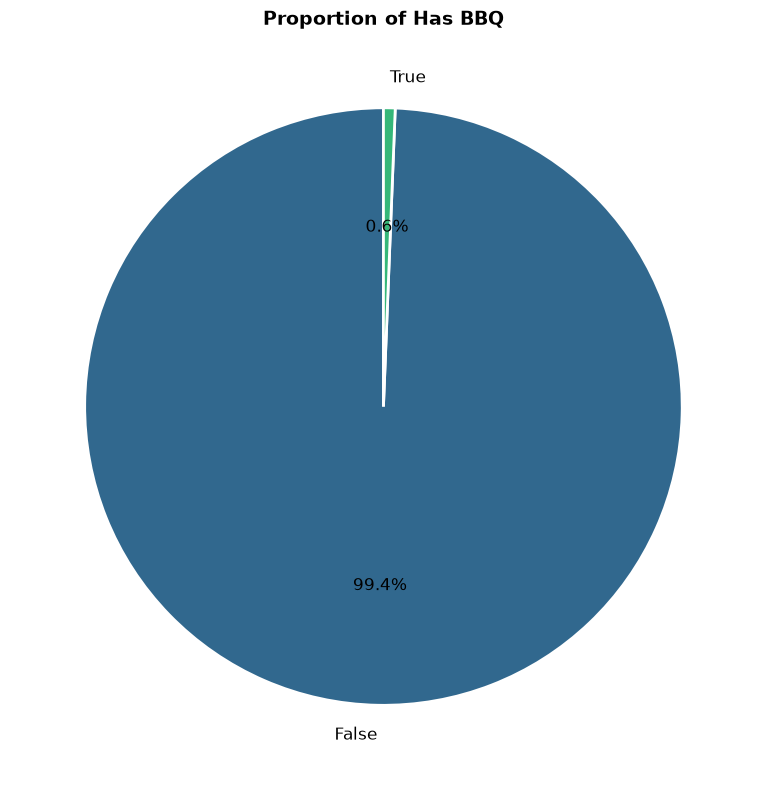

In [30]:
univariate_pie_plot(df,"Has_BBQ")


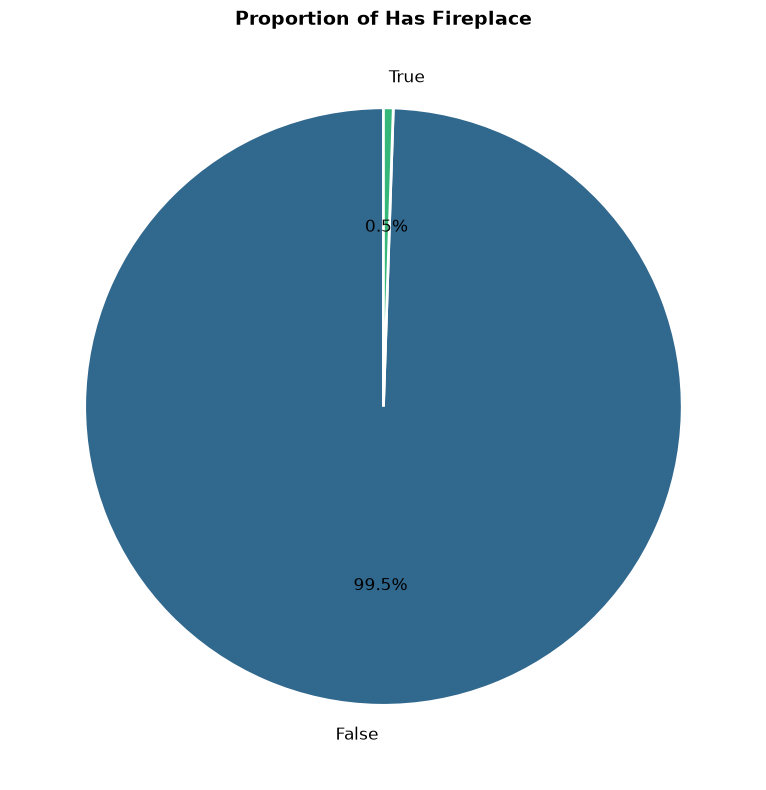

In [31]:
univariate_pie_plot(df,"Has_Fireplace")


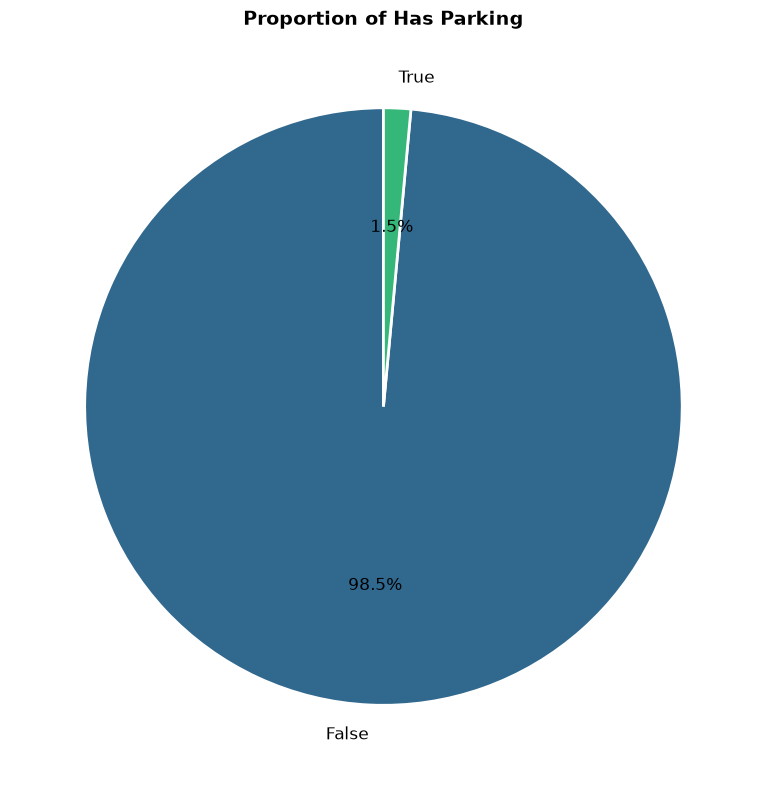

In [32]:
univariate_pie_plot(df,"Has_Parking")


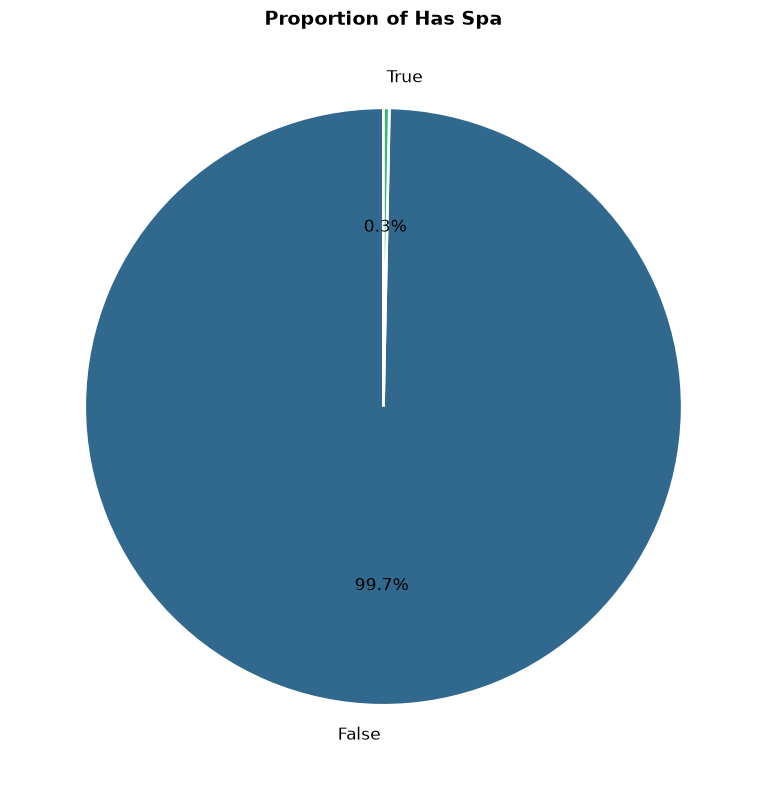

In [33]:
univariate_pie_plot(df,"Has_Spa")


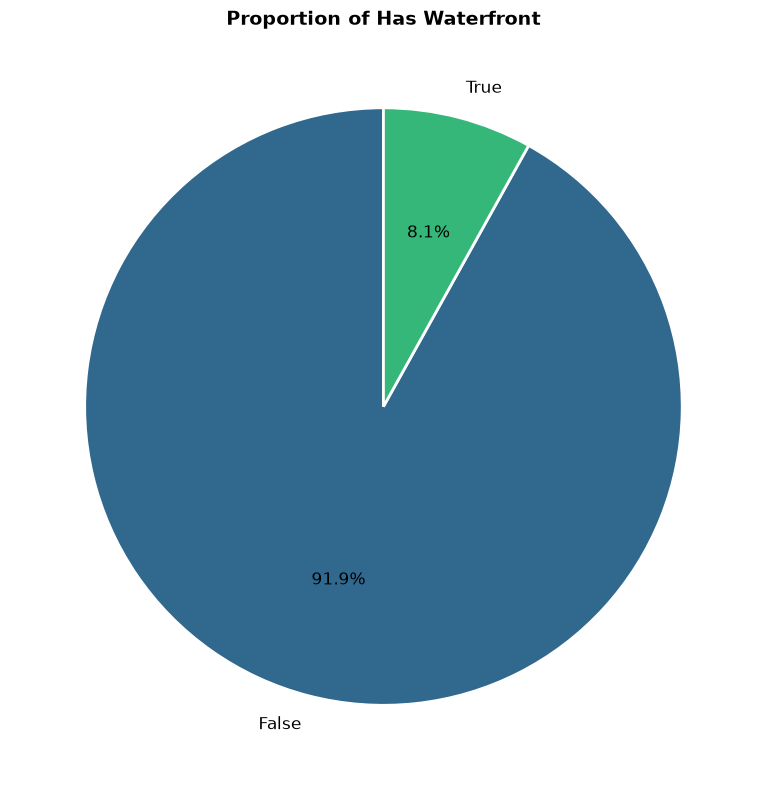

In [34]:
univariate_pie_plot(df,"Has_Waterfront")


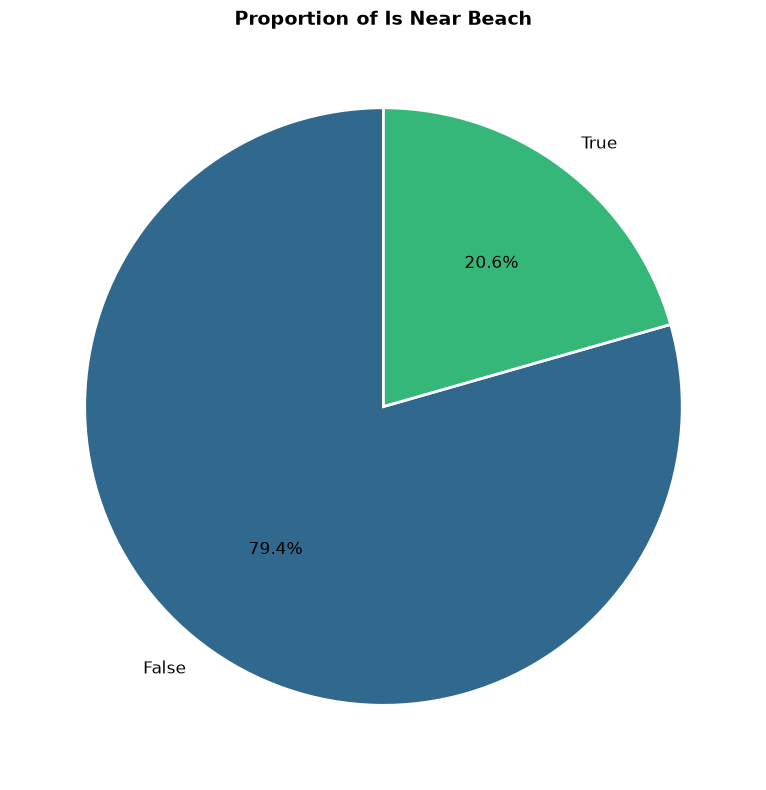

In [35]:
univariate_pie_plot(df,"Is_Near_Beach")


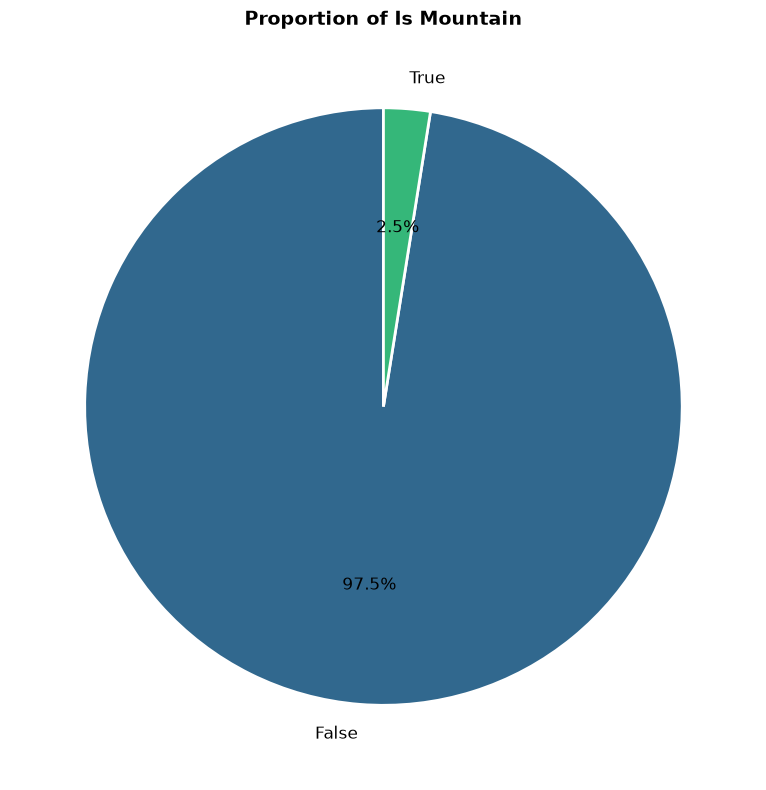

In [36]:
univariate_pie_plot(df,"Is_Mountain")


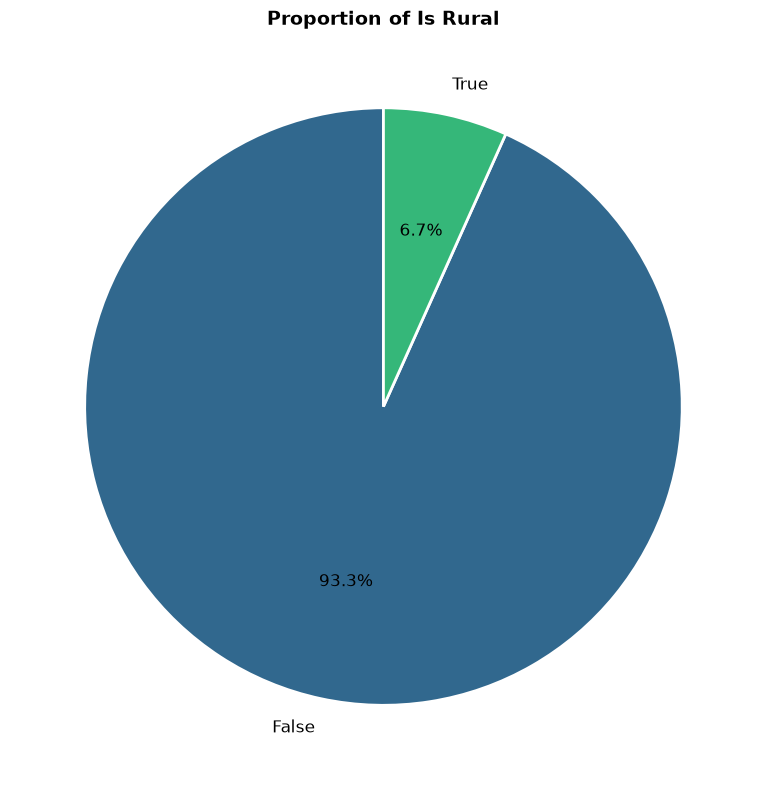

In [37]:
univariate_pie_plot(df,"Is_Rural")


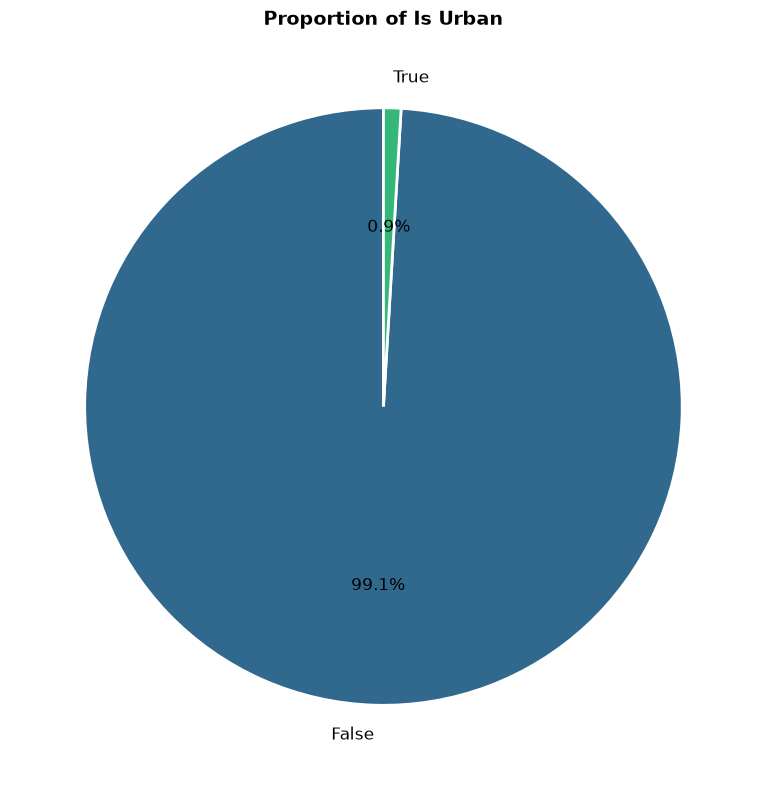

In [38]:
univariate_pie_plot(df,"Is_Urban")


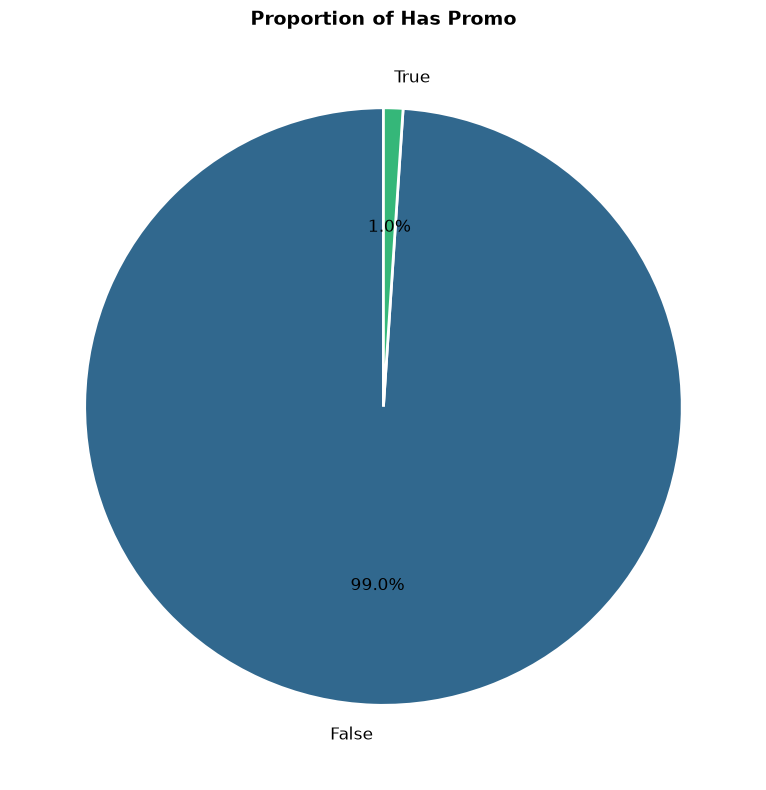

In [39]:
univariate_pie_plot(df,"Has_Promo")


Summary Statistics for: Price
count     953.000000
mean      171.356768
std       141.661126
min        16.000000
25%        83.000000
50%       135.000000
75%       221.000000
max      1463.000000
Name: Price, dtype: float64


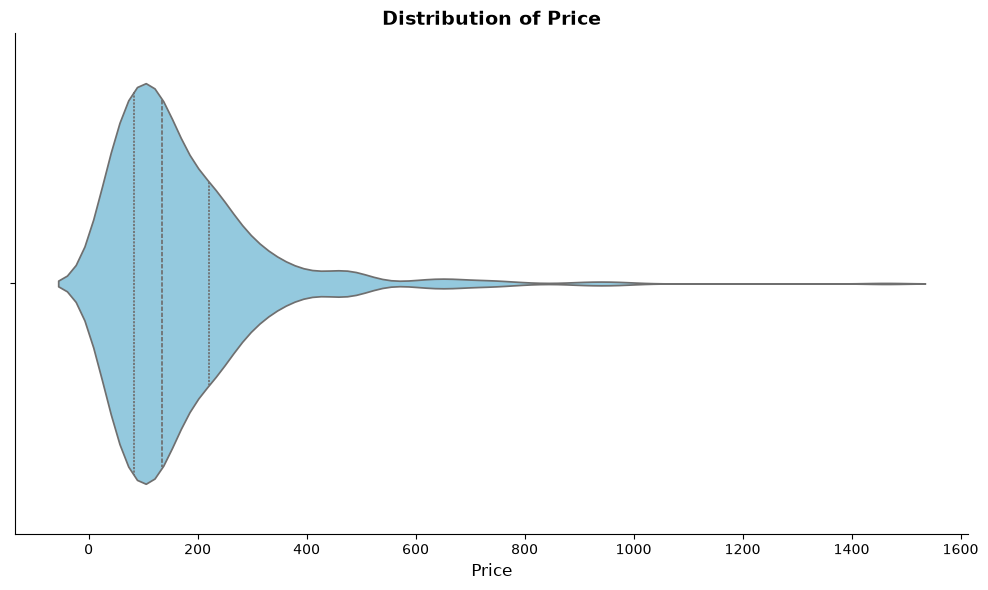

In [40]:
univariate_violin_plot(df,"Price")

Summary Statistics for: Offer_Price
count     166.000000
mean      156.560241
std       152.869937
min        16.000000
25%        63.750000
50%       119.000000
75%       182.000000
max      1089.000000
Name: Offer_Price, dtype: float64


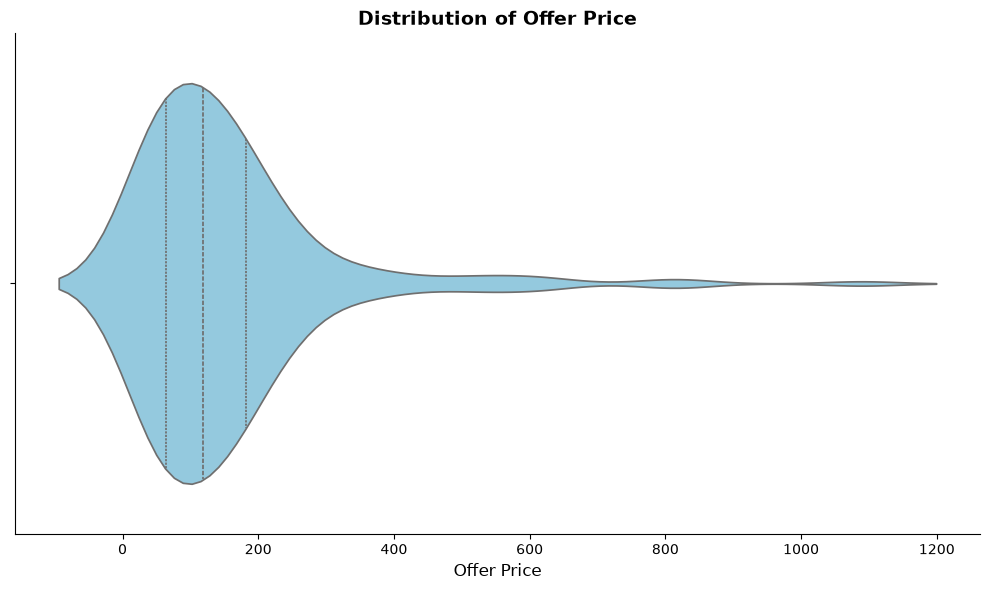

In [41]:
univariate_violin_plot(df,"Offer_Price")


Summary Statistics for: Discount_Pct
count     166.000000
mean      -55.179398
std       273.301111
min     -2351.520000
25%       -48.027500
50%        11.445000
75%        44.732500
max        89.800000
Name: Discount_Pct, dtype: float64


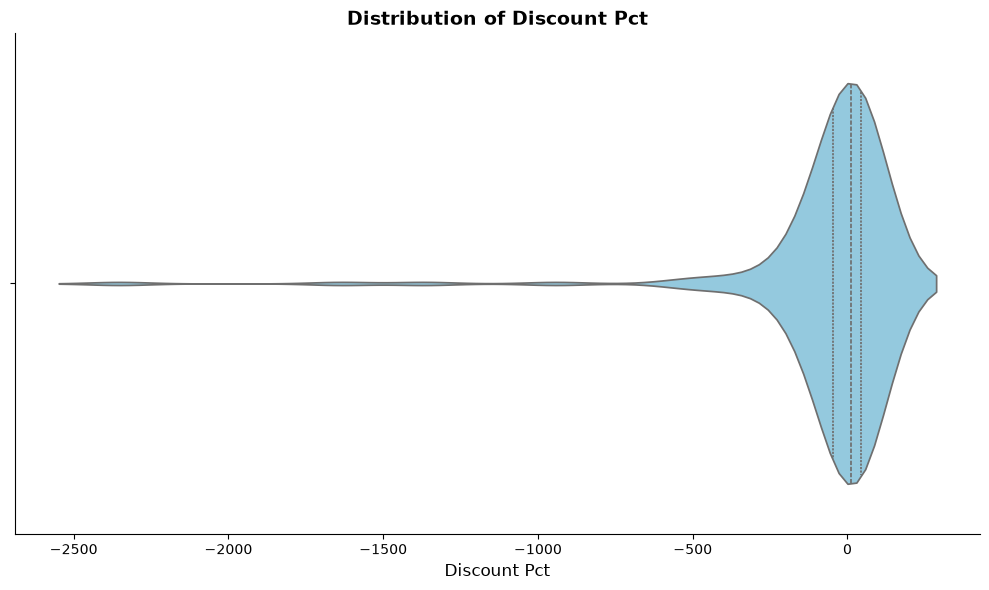

In [42]:
univariate_violin_plot(df,"Discount_Pct")


Summary Statistics for: Price_Per_Night
count    888.000000
mean      33.483806
std       27.654317
min        2.860000
25%       16.400000
50%       26.400000
75%       43.650000
max      292.600000
Name: Price_Per_Night, dtype: float64


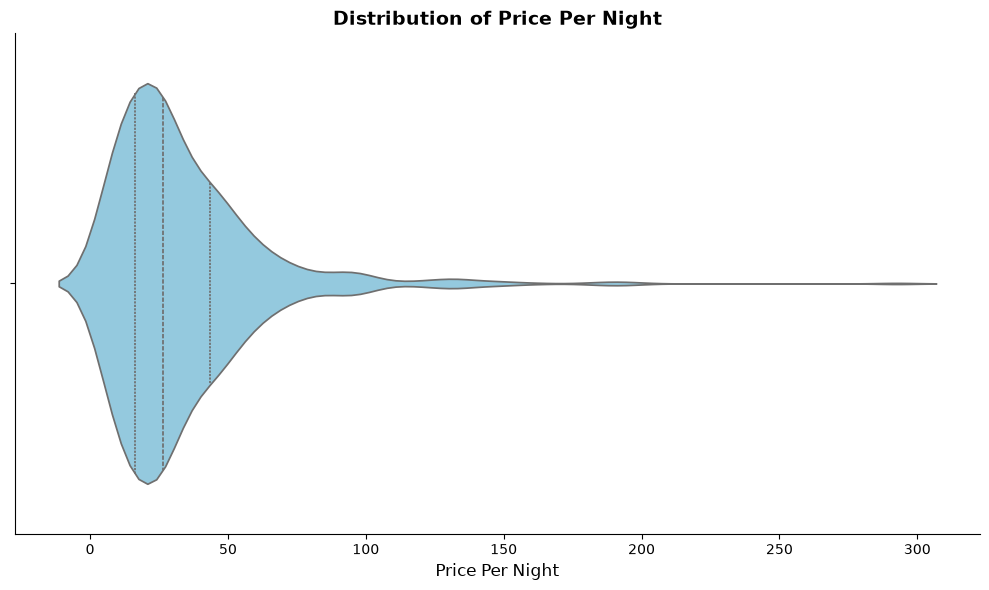

In [43]:
univariate_violin_plot(df,"Price_Per_Night")


Summary Statistics for: Rating
count    931.000000
mean       4.862524
std        0.137328
min        3.670000
25%        4.820000
50%        4.890000
75%        4.960000
max        5.000000
Name: Rating, dtype: float64


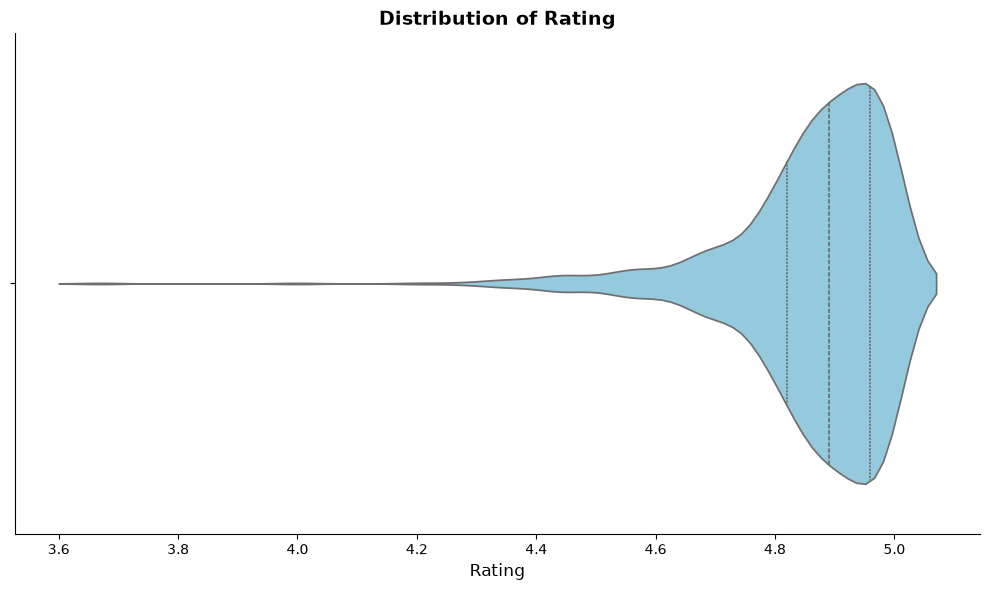

In [44]:
univariate_violin_plot(df,"Rating")


Summary Statistics for: Review_Count
count     947.000000
mean      189.112988
std       185.366539
min         0.000000
25%        54.000000
50%       136.000000
75%       268.000000
max      1239.000000
Name: Review_Count, dtype: float64


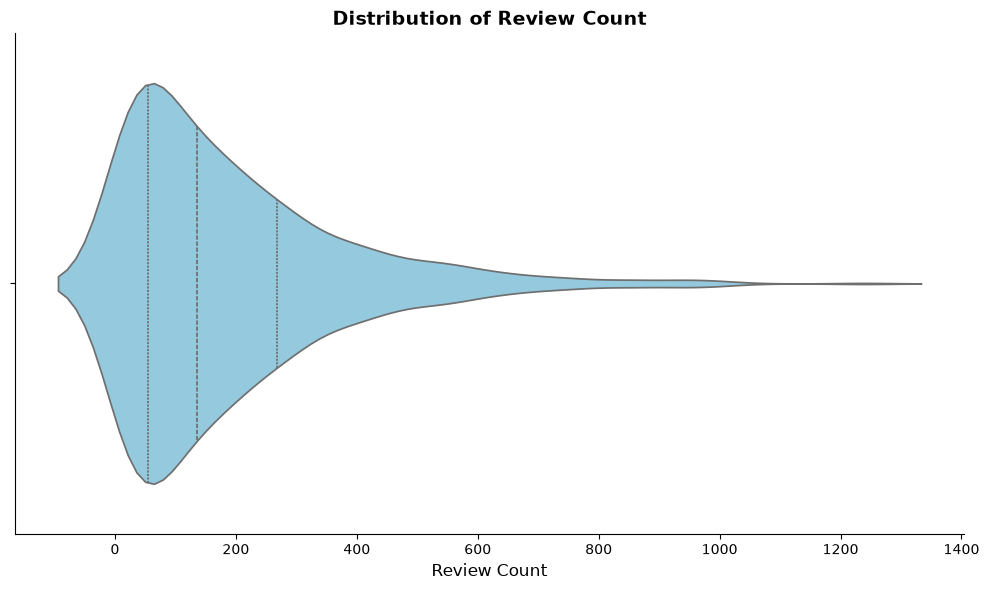

In [45]:
univariate_violin_plot(df,"Review_Count")


Summary Statistics for: Bed_Count
count    953.000000
mean       2.182581
std        1.641835
min        1.000000
25%        1.000000
50%        2.000000
75%        3.000000
max       22.000000
Name: Bed_Count, dtype: float64


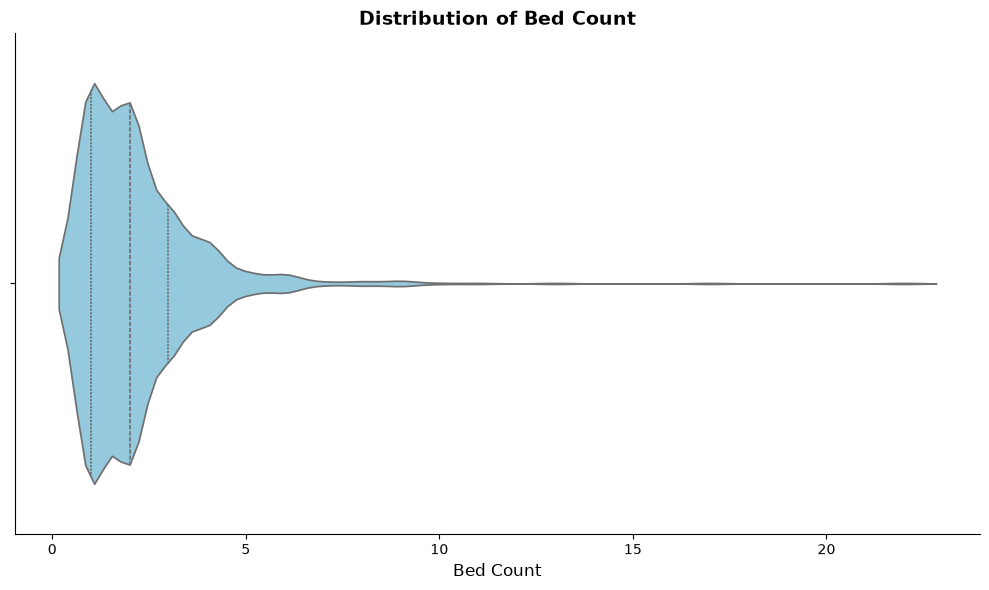

In [46]:
univariate_violin_plot(df,"Bed_Count")


Summary Statistics for: Duration_Nights
count    888.000000
mean       5.148649
std        0.472917
min        5.000000
25%        5.000000
50%        5.000000
75%        5.000000
max        7.000000
Name: Duration_Nights, dtype: float64


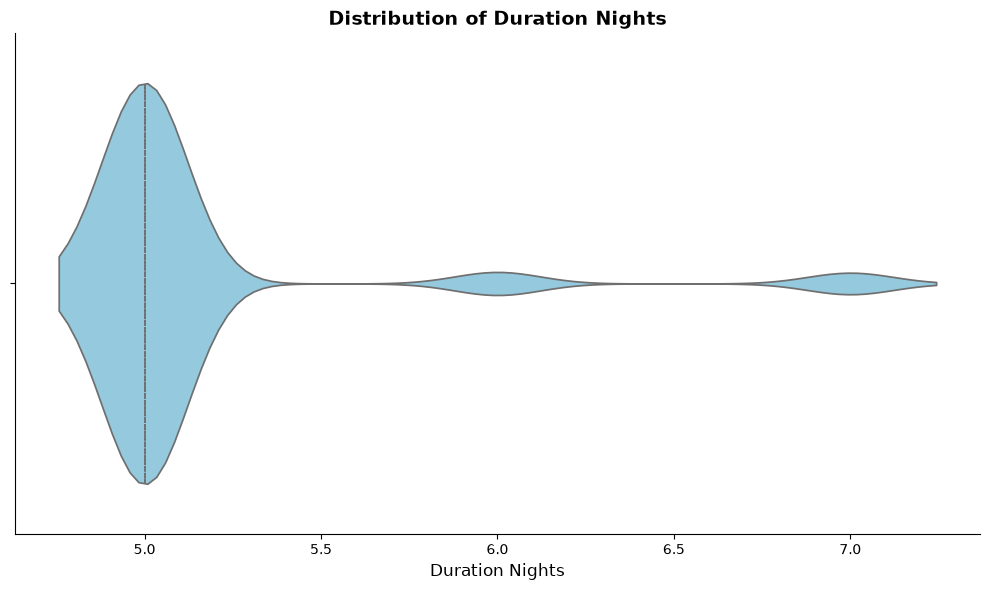

In [47]:
univariate_violin_plot(df,"Duration_Nights")


Summary Statistics for: Detail_Word_Count
count    953.000000
mean       6.385100
std        2.277878
min        1.000000
25%        5.000000
50%        7.000000
75%        8.000000
max       21.000000
Name: Detail_Word_Count, dtype: float64


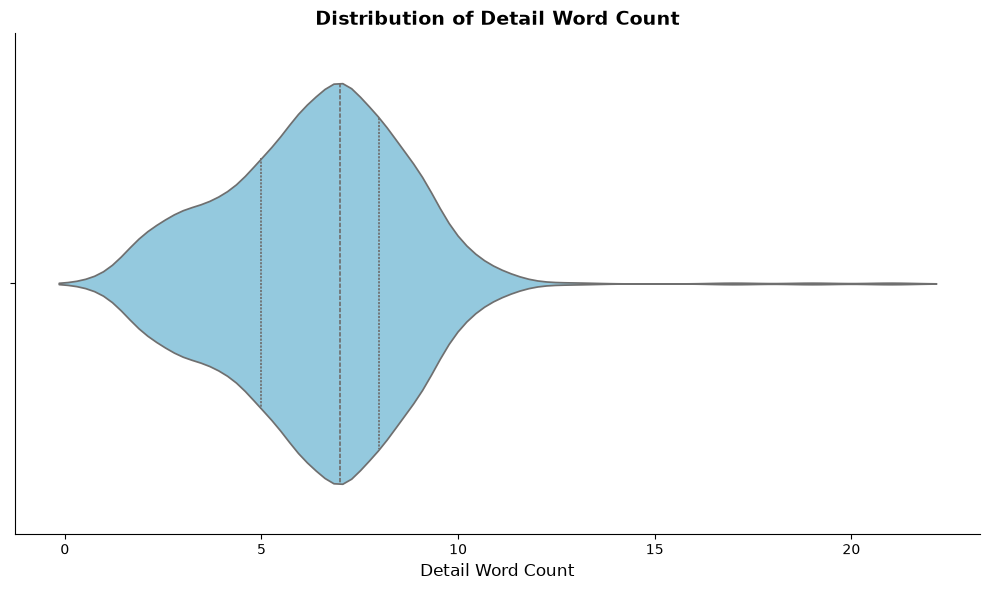

In [48]:
univariate_violin_plot(df,"Detail_Word_Count")


Summary Statistics for: Detail_Char_Count
count    953.000000
mean      38.722980
std       12.276184
min        8.000000
25%       31.000000
50%       42.000000
75%       48.000000
max      129.000000
Name: Detail_Char_Count, dtype: float64


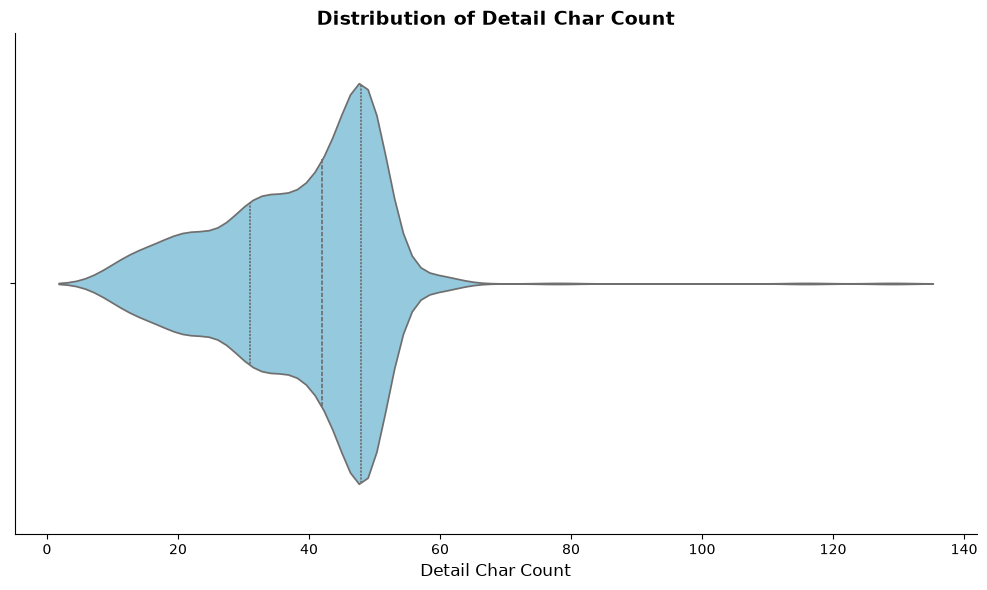

In [49]:
univariate_violin_plot(df,"Detail_Char_Count")
